# Hugging Face Diffusion Course — Unit 1: Introduction to Diffusers

Source: https://huggingface.co/learn/diffusion-course/unit1/1

This notebook starts the Unit 1 work with a small scaffold only. The goal is to keep the first pass close to the official course before adding runnable cells.

# Introduction to 🤗 Diffusers

This notebook follows Hugging Face Diffusion Course Unit 1:

https://huggingface.co/learn/diffusion-course/unit1/1

We will use the original Colab notebook as a guide, but run the work locally in this project.
The goal is to understand the main Diffusers pieces before training a small butterfly image generator.

## What this notebook will build toward

In the original notebook, we eventually:

- try a ready-made diffusion pipeline
- load image data from the Hugging Face Hub
- add noise with a scheduler
- train a small UNet model
- assemble the pieces into a mini image-generation pipeline

For now, we will go step by step and inspect each part before moving on.

## Step 1: Setup check

The Colab notebook installs packages with `%pip install`.
In this local repo, we use `uv` and keep dependencies in `pyproject.toml`.

Before importing anything, confirm that the environment can see the packages we need.

In [7]:
import time

start = time.perf_counter()
import diffusers

elapsed = time.perf_counter() - start

print("diffusers:", diffusers.__version__, f"({elapsed:.2f}s)")

diffusers: 0.38.0 (1.34s)


In [8]:
import time

start = time.perf_counter()
import datasets

elapsed = time.perf_counter() - start

print("datasets:", datasets.__version__, f"({elapsed:.2f}s)")

datasets: 5.0.0 (0.00s)


In [9]:
import time

start = time.perf_counter()
import transformers

elapsed = time.perf_counter() - start

print("transformers:", transformers.__version__, f"({elapsed:.2f}s)")

transformers: 5.12.0 (0.00s)


In [10]:
import time

start = time.perf_counter()
import accelerate

elapsed = time.perf_counter() - start

print("accelerate:", accelerate.__version__, f"({elapsed:.2f}s)")

accelerate: 1.14.0 (0.00s)


In [11]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("torch:", torch.__version__)
print("device:", device)

torch: 2.11.0+cu128
device: cuda


## Step 3: Run a small pretrained pipeline

A pretrained pipeline already has learned model weights.
Instead of training first, we use it to see the full generation process work end to end.

This gives us a reference point for the pieces we will build later: model, scheduler, denoising loop, and final image.

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

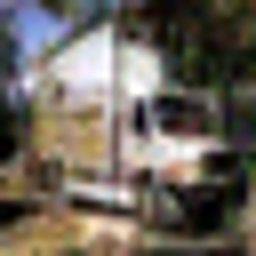

In [18]:
from diffusers import DDPMPipeline

pipeline = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32", use_safetensors=False)
pipeline = pipeline.to(device)

image = pipeline(num_inference_steps=200).images[0]
display(image.resize((256, 256)))